# Notebook 06: Fairness and Subgroup Review

This notebook reviews subgroup performance and outreach selection patterns for the readmission risk model.

The goals are:

- load the test-set risk ranking from Notebook 05
- join subgroup fields back to the ranked test encounters
- review model selection rates across subgroups
- calculate subgroup-level readmission rates
- calculate subgroup-level precision, recall, false positive rate, and false negative rate
- identify areas that would require monitoring before real-world use

This notebook does not claim that the model is fair.

It provides a subgroup review to support responsible interpretation before any operational deployment.

## 1. Imports

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 140)
pd.set_option("display.max_rows", 140)

## 2. Project Paths

In [2]:
def find_project_root(start_path=None):
    """
    Finds the project root by walking upward until the cleaned dataset path is found.
    This avoids relying on the current working directory being exactly the project root
    or the notebooks folder.
    """
    start_path = Path.cwd() if start_path is None else Path(start_path)

    for path in [start_path, *start_path.parents]:
        expected_file = path / "data" / "processed" / "diabetes_readmission_cleaned.csv"
        if expected_file.exists():
            return path

    raise FileNotFoundError(
        "Could not locate project root. Expected to find "
        "'data/processed/diabetes_readmission_cleaned.csv' in this folder or a parent folder."
    )


# Allows the notebook to run whether opened from the project root or the notebooks folder.
PROJECT_ROOT = find_project_root()

DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
OUTPUTS = PROJECT_ROOT / "outputs"
FIGURES = OUTPUTS / "figures"
MODEL_RESULTS = OUTPUTS / "model_results"
OUTREACH_LISTS = OUTPUTS / "outreach_lists"

for path in [DATA_PROCESSED, OUTPUTS, FIGURES, MODEL_RESULTS, OUTREACH_LISTS]:
    path.mkdir(parents=True, exist_ok=True)

print("Project root detected successfully.")
print("Project folder:", PROJECT_ROOT.name)



Project root detected successfully.
Project folder: 03_risk_stratification_intervention_prioritization


## 3. Load Risk Ranking and Model-Ready Data

In [3]:
model_ready_path = DATA_PROCESSED / "diabetes_readmission_model_ready.csv"
test_ranking_path = OUTREACH_LISTS / "test_set_risk_ranking.csv"
selected_model_path = MODEL_RESULTS / "selected_candidate_model.csv"

assert model_ready_path.exists(), f"Missing model-ready dataset: {model_ready_path}"
assert test_ranking_path.exists(), f"Missing test risk ranking: {test_ranking_path}"
assert selected_model_path.exists(), f"Missing selected model output: {selected_model_path}"

df_model = pd.read_csv(model_ready_path, low_memory=False)
test_ranking = pd.read_csv(test_ranking_path, low_memory=False)
selected_model = pd.read_csv(selected_model_path, low_memory=False)

print("Model-ready dataset shape:", df_model.shape)
print("Test ranking shape:", test_ranking.shape)

display(test_ranking.head())
display(selected_model)

Model-ready dataset shape: (101766, 44)
Test ranking shape: (20153, 7)


,encounter_id,patient_nbr,actual_readmitted_30d,predicted_readmission_risk,risk_rank,risk_percentile,risk_tier
0,341998334,88227540,1,0.519773,1,0.000050,Very High Risk - Top 5%
1,362647880,88227540,0,0.516862,2,0.000099,Very High Risk - Top 5%
2,220315764,87452694,1,0.499352,3,0.000149,Very High Risk - Top 5%
3,302587472,88227540,1,0.495687,4,0.000198,Very High Risk - Top 5%
4,189144708,42941232,1,0.484275,5,0.000248,Very High Risk - Top 5%


,model,accuracy,precision,recall,f1,roc_auc,pr_auc
0,Gradient Boosting,0.893267,0.5,0.000465,0.000929,0.66626,0.206588


In [4]:
required_ranking_columns = [
    "encounter_id",
    "patient_nbr",
    "actual_readmitted_30d",
    "predicted_readmission_risk",
    "risk_rank",
    "risk_percentile",
    "risk_tier"
]

missing_ranking_columns = [
    col for col in required_ranking_columns
    if col not in test_ranking.columns
]

assert len(missing_ranking_columns) == 0, f"Missing ranking columns: {missing_ranking_columns}"

subgroup_columns = [
    "age",
    "race",
    "gender"
]

missing_subgroup_columns = [
    col for col in subgroup_columns
    if col not in df_model.columns
]

assert len(missing_subgroup_columns) == 0, f"Missing subgroup columns: {missing_subgroup_columns}"

print("Required ranking and subgroup columns found.")

Required ranking and subgroup columns found.


### Interpretation

This notebook uses the test-set risk ranking created in Notebook 05.

The ranking contains predicted readmission risk, risk rank, risk percentile, and risk tier.

Subgroup fields are loaded from the model-ready dataset and joined back by `encounter_id`.

## 4. Join Subgroup Fields to Risk Ranking

In [5]:
subgroup_lookup = df_model[
    ["encounter_id"] + subgroup_columns
].copy()

analysis_df = test_ranking.merge(
    subgroup_lookup,
    on="encounter_id",
    how="left",
    validate="one_to_one"
)

assert len(analysis_df) == len(test_ranking), "Row count changed after subgroup join."

print("Analysis dataset shape:", analysis_df.shape)
display(analysis_df.head())

Analysis dataset shape: (20153, 10)


,encounter_id,patient_nbr,actual_readmitted_30d,predicted_readmission_risk,risk_rank,risk_percentile,risk_tier,age,race,gender
0,341998334,88227540,1,0.519773,1,0.000050,Very High Risk - Top 5%,[40-50),AfricanAmerican,Female
1,362647880,88227540,0,0.516862,2,0.000099,Very High Risk - Top 5%,[40-50),AfricanAmerican,Female
2,220315764,87452694,1,0.499352,3,0.000149,Very High Risk - Top 5%,[70-80),Caucasian,Female
3,302587472,88227540,1,0.495687,4,0.000198,Very High Risk - Top 5%,[40-50),AfricanAmerican,Female
4,189144708,42941232,1,0.484275,5,0.000248,Very High Risk - Top 5%,[70-80),Caucasian,Male


In [6]:
# Use rank-based cutoffs to stay consistent with Notebook 05 threshold logic.
n_test = len(analysis_df)

top_5_cutoff = int(np.ceil(n_test * 0.05))
top_10_cutoff = int(np.ceil(n_test * 0.10))
top_20_cutoff = int(np.ceil(n_test * 0.20))

analysis_df["top_5_selected"] = np.where(
    analysis_df["risk_rank"] <= top_5_cutoff,
    1,
    0
)

analysis_df["top_10_selected"] = np.where(
    analysis_df["risk_rank"] <= top_10_cutoff,
    1,
    0
)

analysis_df["top_20_selected"] = np.where(
    analysis_df["risk_rank"] <= top_20_cutoff,
    1,
    0
)

selection_summary = pd.DataFrame({
    "threshold": ["Top 5%", "Top 10%", "Top 20%"],
    "rank_cutoff": [top_5_cutoff, top_10_cutoff, top_20_cutoff],
    "selected_encounters": [
        analysis_df["top_5_selected"].sum(),
        analysis_df["top_10_selected"].sum(),
        analysis_df["top_20_selected"].sum()
    ],
    "selection_rate": [
        analysis_df["top_5_selected"].mean(),
        analysis_df["top_10_selected"].mean(),
        analysis_df["top_20_selected"].mean()
    ],
    "observed_readmission_rate": [
        analysis_df.loc[analysis_df["top_5_selected"] == 1, "actual_readmitted_30d"].mean(),
        analysis_df.loc[analysis_df["top_10_selected"] == 1, "actual_readmitted_30d"].mean(),
        analysis_df.loc[analysis_df["top_20_selected"] == 1, "actual_readmitted_30d"].mean()
    ]
})

display(selection_summary.round(4))

,threshold,rank_cutoff,selected_encounters,selection_rate,observed_readmission_rate
0,Top 5%,1008,1008,0.05,0.3006
1,Top 10%,2016,2016,0.10,0.2579
2,Top 20%,4031,4031,0.20,0.2039


### Interpretation

Threshold flags are assigned using rank-based cutoffs to stay consistent with the risk-tier and outreach-list logic created in Notebook 05.

The top 10% risk group is treated as the provisional outreach threshold.

This does not mean the model predicts readmission with certainty.

It means the model ranks these encounters as the highest-risk group under limited outreach capacity.

## 5. Subgroup Review Helper Function

In [7]:
def summarize_subgroup_performance(data, subgroup_col, selection_col="top_10_selected", target_col="actual_readmitted_30d"):
    """
    Summarizes subgroup-level outcome, selection, and performance metrics.

    The selection column represents the operational outreach threshold.
    For example, top_10_selected = 1 means the encounter was selected into the top 10% highest-risk group.
    """
    rows = []

    for subgroup_value, group in data.groupby(subgroup_col, dropna=False, observed=False):
        total_encounters = len(group)
        actual_positive = int(group[target_col].sum())
        actual_negative = total_encounters - actual_positive

        selected = int(group[selection_col].sum())
        not_selected = total_encounters - selected

        true_positive = int(((group[selection_col] == 1) & (group[target_col] == 1)).sum())
        false_positive = int(((group[selection_col] == 1) & (group[target_col] == 0)).sum())
        false_negative = int(((group[selection_col] == 0) & (group[target_col] == 1)).sum())
        true_negative = int(((group[selection_col] == 0) & (group[target_col] == 0)).sum())

        rows.append({
            "subgroup_variable": subgroup_col,
            "subgroup_value": subgroup_value,
            "encounter_count": total_encounters,
            "readmission_count": actual_positive,
            "readmission_rate": actual_positive / total_encounters if total_encounters > 0 else np.nan,
            "avg_predicted_risk": group["predicted_readmission_risk"].mean(),
            "selected_count": selected,
            "selection_rate": selected / total_encounters if total_encounters > 0 else np.nan,
            "true_positive": true_positive,
            "false_positive": false_positive,
            "false_negative": false_negative,
            "true_negative": true_negative,
            "precision": true_positive / selected if selected > 0 else np.nan,
            "recall": true_positive / actual_positive if actual_positive > 0 else np.nan,
            "false_positive_rate": false_positive / actual_negative if actual_negative > 0 else np.nan,
            "false_negative_rate": false_negative / actual_positive if actual_positive > 0 else np.nan
        })

    return pd.DataFrame(rows)

### Metric Definitions

For this notebook, the top 10% selected group is treated as the operational positive group.

Definitions:

- **Selection rate**: percentage of subgroup encounters selected into the top 10%
- **Precision**: among selected subgroup encounters, percentage actually readmitted
- **Recall**: among readmitted subgroup encounters, percentage selected into the top 10%
- **False positive rate**: among non-readmitted subgroup encounters, percentage selected
- **False negative rate**: among readmitted subgroup encounters, percentage not selected
- **avg_predicted_risk**: represents the subgroup's average model score. Because probability calibration has not yet been completed, these values are used for relative comparison and ranking rather than interpreted as calibrated absolute readmission probabilities.

These metrics support monitoring. They do not prove the model is fair.

## 6. Age Group Review

In [8]:
age_review = summarize_subgroup_performance(
    data=analysis_df,
    subgroup_col="age",
    selection_col="top_10_selected"
)

age_order = [
    "[0-10)", "[10-20)", "[20-30)", "[30-40)", "[40-50)",
    "[50-60)", "[60-70)", "[70-80)", "[80-90)", "[90-100)"
]

age_review["subgroup_value"] = pd.Categorical(
    age_review["subgroup_value"],
    categories=age_order,
    ordered=True
)

age_review = age_review.sort_values("subgroup_value")

display(age_review.round(4))

,subgroup_variable,subgroup_value,encounter_count,readmission_count,readmission_rate,avg_predicted_risk,selected_count,selection_rate,true_positive,false_positive,false_negative,true_negative,precision,recall,false_positive_rate,false_negative_rate
0,age,[0-10),38,2,0.0526,0.0666,0,0.0000,0,0,2,36,NaN,0.0000,0.0000,1.0000
1,age,[10-20),137,5,0.0365,0.0908,13,0.0949,1,12,4,120,0.0769,0.2000,0.0909,0.8000
2,age,[20-30),285,23,0.0807,0.0979,33,0.1158,2,31,21,231,0.0606,0.0870,0.1183,0.9130
3,age,[30-40),804,99,0.1231,0.1128,134,0.1667,35,99,64,606,0.2612,0.3535,0.1404,0.6465
4,age,[40-50),1893,193,0.1020,0.1074,202,0.1067,62,140,131,1560,0.3069,0.3212,0.0824,0.6788
5,age,[50-60),3518,356,0.1012,0.1022,295,0.0839,82,213,274,2949,0.2780,0.2303,0.0674,0.7697
6,age,[60-70),4511,465,0.1031,0.1130,453,0.1004,115,338,350,3708,0.2539,0.2473,0.0835,0.7527
7,age,[70-80),5125,560,0.1093,0.1149,504,0.0983,131,373,429,4192,0.2599,0.2339,0.0817,0.7661
8,age,[80-90),3314,403,0.1216,0.1192,349,0.1053,88,261,315,2650,0.2521,0.2184,0.0897,0.7816
9,age,[90-100),528,45,0.0852,0.1154,33,0.0625,4,29,41,454,0.1212,0.0889,0.0600,0.9111


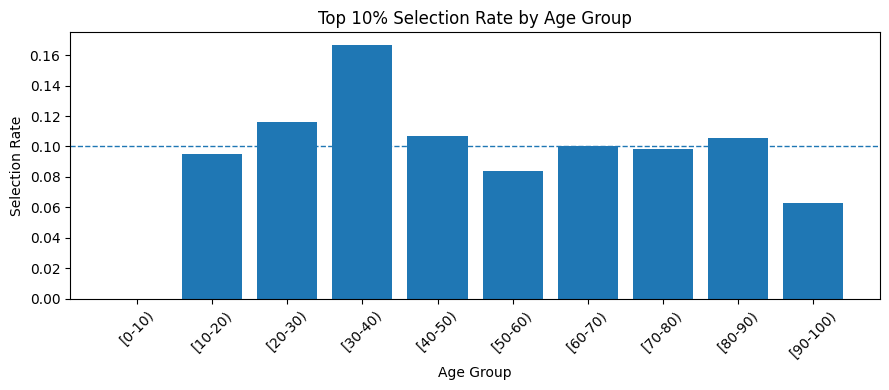

In [9]:
plt.figure(figsize=(9, 4))
plt.bar(
    age_review["subgroup_value"].astype(str),
    age_review["selection_rate"]
)
plt.axhline(analysis_df["top_10_selected"].mean(), linestyle="--", linewidth=1)
plt.title("Top 10% Selection Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Selection Rate")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(FIGURES / "top_10_selection_rate_by_age.png", dpi=300)
plt.show()

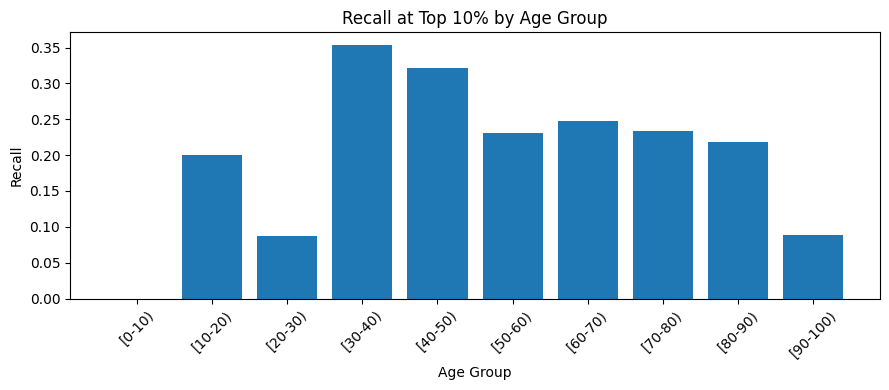

In [10]:
plt.figure(figsize=(9, 4))
plt.bar(
    age_review["subgroup_value"].astype(str),
    age_review["recall"]
)
plt.title("Recall at Top 10% by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Recall")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(FIGURES / "recall_at_top_10_by_age.png", dpi=300)
plt.show()

### Interpretation

Age is both clinically relevant and sensitive from a subgroup-monitoring perspective.

Large differences in selection rate or recall across age groups should be reviewed carefully.

A higher selection rate may reflect higher predicted risk, but it may also reflect model behavior, utilization patterns, or historical data patterns.

## 7. Race Group Review

In [11]:
race_review = summarize_subgroup_performance(
    data=analysis_df,
    subgroup_col="race",
    selection_col="top_10_selected"
)

race_review = race_review.sort_values("encounter_count", ascending=False)
race_review["subgroup_value"] = race_review["subgroup_value"].fillna("Unknown").astype(str)

display(race_review.round(4))

,subgroup_variable,subgroup_value,encounter_count,readmission_count,readmission_rate,avg_predicted_risk,selected_count,selection_rate,true_positive,false_positive,false_negative,true_negative,precision,recall,false_positive_rate,false_negative_rate
2,race,Caucasian,15089,1626,0.1078,0.1125,1491,0.0988,381,1110,1245,12353,0.2555,0.2343,0.0824,0.7657
0,race,AfricanAmerican,3847,425,0.1105,0.1123,436,0.1133,119,317,306,3105,0.2729,0.2800,0.0926,0.7200
5,race,Unknown,410,21,0.0512,0.0947,19,0.0463,1,18,20,371,0.0526,0.0476,0.0463,0.9524
3,race,Hispanic,393,31,0.0789,0.1025,30,0.0763,7,23,24,339,0.2333,0.2258,0.0635,0.7742
4,race,Other,289,29,0.1003,0.1032,25,0.0865,8,17,21,243,0.3200,0.2759,0.0654,0.7241
1,race,Asian,125,19,0.1520,0.1073,15,0.1200,4,11,15,95,0.2667,0.2105,0.1038,0.7895


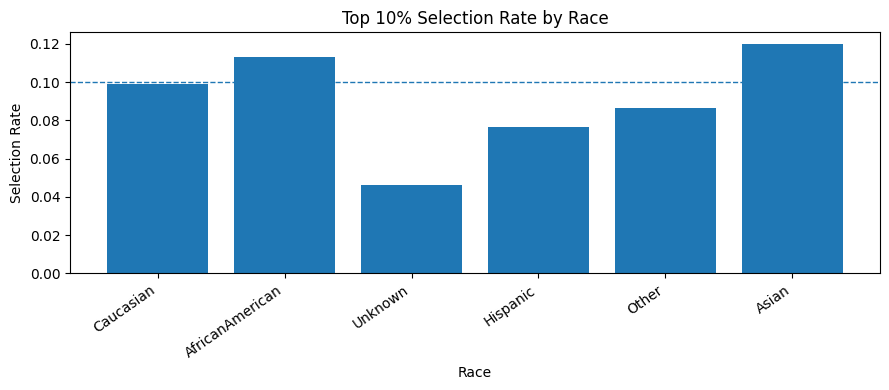

In [12]:
plt.figure(figsize=(9, 4))
plt.bar(
    race_review["subgroup_value"].astype(str),
    race_review["selection_rate"]
)
plt.axhline(analysis_df["top_10_selected"].mean(), linestyle="--", linewidth=1)
plt.title("Top 10% Selection Rate by Race")
plt.xlabel("Race")
plt.ylabel("Selection Rate")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()


plt.savefig(FIGURES / "top_10_selection_rate_by_race.png", dpi=300)
plt.show()

### Interpretation

Race is a sensitive demographic field.

This notebook does not use race to claim fairness or unfairness.

The review checks whether selection rates, recall, precision, false positive rates, or false negative rates vary across race groups.

Differences may reflect sample size, documentation patterns, clinical mix, utilization history, structural inequities, or model behavior.

## 8. Gender Group Review

In [13]:
gender_review = summarize_subgroup_performance(
    data=analysis_df,
    subgroup_col="gender",
    selection_col="top_10_selected"
)

gender_review = gender_review.sort_values("encounter_count", ascending=False)

display(gender_review.round(4))

,subgroup_variable,subgroup_value,encounter_count,readmission_count,readmission_rate,avg_predicted_risk,selected_count,selection_rate,true_positive,false_positive,false_negative,true_negative,precision,recall,false_positive_rate,false_negative_rate
0,gender,Female,10871,1157,0.1064,0.1133,1114,0.1025,273,841,884,8873,0.2451,0.2360,0.0866,0.7640
1,gender,Male,9280,994,0.1071,0.1098,901,0.0971,247,654,747,7632,0.2741,0.2485,0.0789,0.7515
2,gender,Unknown/Invalid,2,0,0.0000,0.1471,1,0.5000,0,1,0,1,0.0000,NaN,0.5000,NaN


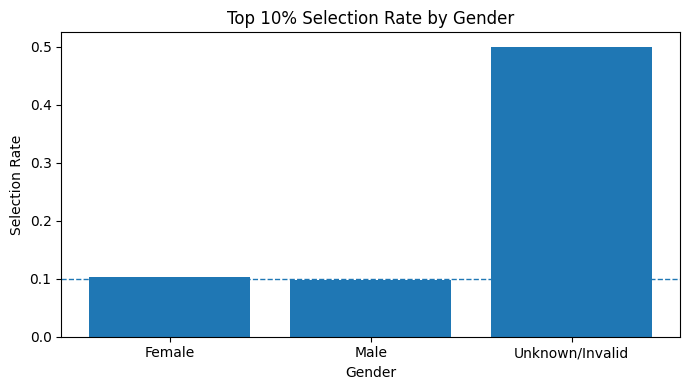

In [14]:
plt.figure(figsize=(7, 4))
plt.bar(
    gender_review["subgroup_value"].astype(str),
    gender_review["selection_rate"]
)
plt.axhline(analysis_df["top_10_selected"].mean(), linestyle="--", linewidth=1)
plt.title("Top 10% Selection Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Selection Rate")
plt.tight_layout()

plt.savefig(FIGURES / "top_10_selection_rate_by_gender.png", dpi=300)
plt.show()

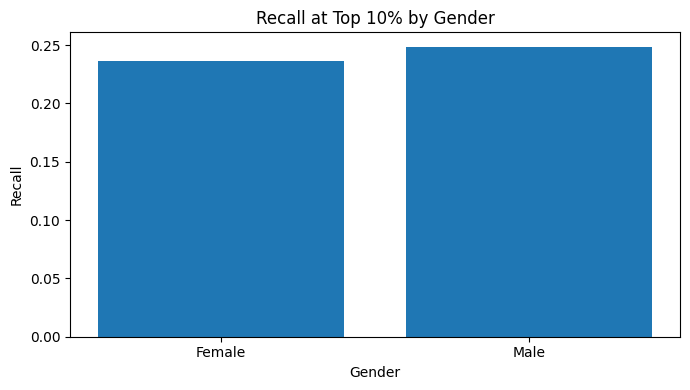

In [15]:
plt.figure(figsize=(7, 4))
plt.bar(
    gender_review["subgroup_value"].astype(str),
    gender_review["recall"]
)
plt.title("Recall at Top 10% by Gender")
plt.xlabel("Gender")
plt.ylabel("Recall")
plt.tight_layout()

plt.savefig(FIGURES / "recall_at_top_10_by_gender.png", dpi=300)
plt.show()

### Interpretation

Gender subgroup metrics should be reviewed for selection and performance differences.

If a subgroup has very small sample size, its metrics may be unstable.

Subgroup differences should be flagged for monitoring, not over-interpreted from a single retrospective test set.

## 9. Combined Subgroup Review Table

In [16]:
subgroup_reviews = pd.concat(
    [
        age_review,
        race_review,
        gender_review
    ],
    ignore_index=True
)

display(
    subgroup_reviews
    .sort_values(["subgroup_variable", "encounter_count"], ascending=[True, False])
    .round(4)
)

,subgroup_variable,subgroup_value,encounter_count,readmission_count,readmission_rate,avg_predicted_risk,selected_count,selection_rate,true_positive,false_positive,false_negative,true_negative,precision,recall,false_positive_rate,false_negative_rate
7,age,[70-80),5125,560,0.1093,0.1149,504,0.0983,131,373,429,4192,0.2599,0.2339,0.0817,0.7661
6,age,[60-70),4511,465,0.1031,0.1130,453,0.1004,115,338,350,3708,0.2539,0.2473,0.0835,0.7527
5,age,[50-60),3518,356,0.1012,0.1022,295,0.0839,82,213,274,2949,0.2780,0.2303,0.0674,0.7697
8,age,[80-90),3314,403,0.1216,0.1192,349,0.1053,88,261,315,2650,0.2521,0.2184,0.0897,0.7816
4,age,[40-50),1893,193,0.1020,0.1074,202,0.1067,62,140,131,1560,0.3069,0.3212,0.0824,0.6788
3,age,[30-40),804,99,0.1231,0.1128,134,0.1667,35,99,64,606,0.2612,0.3535,0.1404,0.6465
9,age,[90-100),528,45,0.0852,0.1154,33,0.0625,4,29,41,454,0.1212,0.0889,0.0600,0.9111
2,age,[20-30),285,23,0.0807,0.0979,33,0.1158,2,31,21,231,0.0606,0.0870,0.1183,0.9130
1,age,[10-20),137,5,0.0365,0.0908,13,0.0949,1,12,4,120,0.0769,0.2000,0.0909,0.8000
0,age,[0-10),38,2,0.0526,0.0666,0,0.0000,0,0,2,36,NaN,0.0000,0.0000,1.0000


In [17]:
min_subgroup_size = 100

subgroup_monitoring_flags = subgroup_reviews.copy()

subgroup_monitoring_flags["small_sample_flag"] = np.where(
    subgroup_monitoring_flags["encounter_count"] < min_subgroup_size,
    1,
    0
)

overall_selection_rate = analysis_df["top_10_selected"].mean()
overall_recall = (
    analysis_df.loc[
        analysis_df["actual_readmitted_30d"] == 1,
        "top_10_selected"
    ].mean()
)

subgroup_monitoring_flags["selection_rate_diff_vs_overall"] = (
    subgroup_monitoring_flags["selection_rate"] - overall_selection_rate
)

subgroup_monitoring_flags["recall_diff_vs_overall"] = (
    subgroup_monitoring_flags["recall"] - overall_recall
)

display(subgroup_monitoring_flags.round(4))

,subgroup_variable,subgroup_value,encounter_count,readmission_count,readmission_rate,avg_predicted_risk,selected_count,selection_rate,true_positive,false_positive,false_negative,true_negative,precision,recall,false_positive_rate,false_negative_rate,small_sample_flag,selection_rate_diff_vs_overall,recall_diff_vs_overall
0,age,[0-10),38,2,0.0526,0.0666,0,0.0000,0,0,2,36,NaN,0.0000,0.0000,1.0000,1,-0.1000,-0.2417
1,age,[10-20),137,5,0.0365,0.0908,13,0.0949,1,12,4,120,0.0769,0.2000,0.0909,0.8000,0,-0.0051,-0.0417
2,age,[20-30),285,23,0.0807,0.0979,33,0.1158,2,31,21,231,0.0606,0.0870,0.1183,0.9130,0,0.0158,-0.1548
3,age,[30-40),804,99,0.1231,0.1128,134,0.1667,35,99,64,606,0.2612,0.3535,0.1404,0.6465,0,0.0666,0.1118
4,age,[40-50),1893,193,0.1020,0.1074,202,0.1067,62,140,131,1560,0.3069,0.3212,0.0824,0.6788,0,0.0067,0.0795
5,age,[50-60),3518,356,0.1012,0.1022,295,0.0839,82,213,274,2949,0.2780,0.2303,0.0674,0.7697,0,-0.0162,-0.0114
6,age,[60-70),4511,465,0.1031,0.1130,453,0.1004,115,338,350,3708,0.2539,0.2473,0.0835,0.7527,0,0.0004,0.0056
7,age,[70-80),5125,560,0.1093,0.1149,504,0.0983,131,373,429,4192,0.2599,0.2339,0.0817,0.7661,0,-0.0017,-0.0078
8,age,[80-90),3314,403,0.1216,0.1192,349,0.1053,88,261,315,2650,0.2521,0.2184,0.0897,0.7816,0,0.0053,-0.0234
9,age,[90-100),528,45,0.0852,0.1154,33,0.0625,4,29,41,454,0.1212,0.0889,0.0600,0.9111,0,-0.0375,-0.1529


### Interpretation

The combined table makes subgroup differences easier to compare.

Important review fields:

- subgroup sample size
- observed readmission rate
- average predicted risk
- top 10% selection rate
- precision
- recall
- false positive rate
- false negative rate

Small subgroups should be interpreted cautiously because metrics can be unstable.

## 10. Selection Rate vs. Observed Readmission Rate

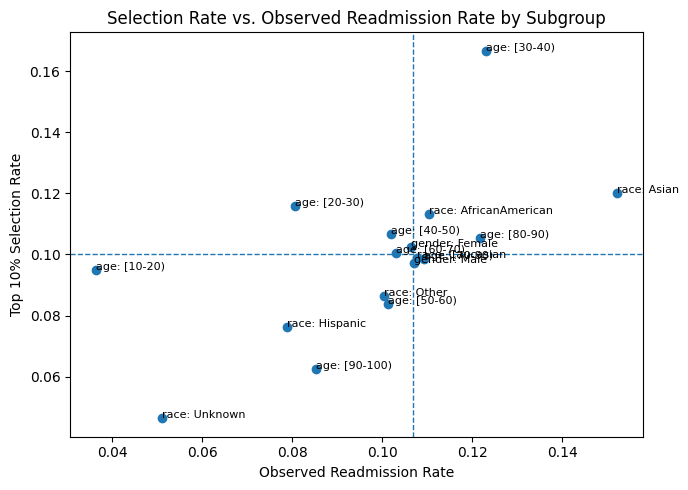

In [18]:
plot_df = subgroup_reviews[
    subgroup_reviews["encounter_count"] >= min_subgroup_size
].copy()

plt.figure(figsize=(7, 5))
plt.scatter(
    plot_df["readmission_rate"],
    plot_df["selection_rate"]
)

for _, row in plot_df.iterrows():
    label = f"{row['subgroup_variable']}: {row['subgroup_value']}"
    plt.annotate(
        label,
        (row["readmission_rate"], row["selection_rate"]),
        fontsize=8,
        alpha=1.0
    )

plt.axhline(overall_selection_rate, linestyle="--", linewidth=1)
plt.axvline(analysis_df["actual_readmitted_30d"].mean(), linestyle="--", linewidth=1)
plt.title("Selection Rate vs. Observed Readmission Rate by Subgroup")
plt.xlabel("Observed Readmission Rate")
plt.ylabel("Top 10% Selection Rate")
plt.tight_layout()

plt.savefig(FIGURES / "selection_rate_vs_readmission_rate_by_subgroup.png", dpi=300)
plt.show()

### Interpretation

This chart compares subgroup selection rates against subgroup observed readmission rates.

A subgroup with higher observed readmission risk may reasonably have a higher selection rate.

However, selection differences should still be monitored because they may reflect model bias, data quality issues, or structural inequities.

## 11. Fairness Review Notes

This notebook is a subgroup monitoring review, not a final fairness approval.

Important cautions:

- Race, gender, and age are sensitive fields.
- Subgroup sample sizes may vary.
- Performance differences may reflect clinical mix, utilization patterns, documentation quality, structural inequities, or model behavior.
- A retrospective subgroup review cannot prove that the model is fair.
- Any real-world use would require ongoing monitoring after deployment.

Operational monitoring should include:

- selection rate by subgroup
- outreach completion rate by subgroup
- readmission rate by subgroup
- false negative rate by subgroup
- appeal/review workflow for high-risk and missed cases
- periodic recalibration checks

## 12. Export Outputs

In [19]:
age_review_output_path = MODEL_RESULTS / "subgroup_review_age.csv"
race_review_output_path = MODEL_RESULTS / "subgroup_review_race.csv"
gender_review_output_path = MODEL_RESULTS / "subgroup_review_gender.csv"
selection_summary_output_path = MODEL_RESULTS / "subgroup_threshold_selection_summary.csv"
combined_review_output_path = MODEL_RESULTS / "subgroup_review_combined.csv"
monitoring_flags_output_path = MODEL_RESULTS / "subgroup_monitoring_flags.csv"
analysis_output_path = MODEL_RESULTS / "test_ranking_with_subgroups.csv"

age_review.to_csv(age_review_output_path, index=False)
race_review.to_csv(race_review_output_path, index=False)
gender_review.to_csv(gender_review_output_path, index=False)
selection_summary.to_csv(selection_summary_output_path, index=False)
subgroup_reviews.to_csv(combined_review_output_path, index=False)
subgroup_monitoring_flags.to_csv(monitoring_flags_output_path, index=False)
analysis_df.to_csv(analysis_output_path, index=False)

print("Saved age subgroup review to:", age_review_output_path.relative_to(PROJECT_ROOT))
print("Saved race subgroup review to:", race_review_output_path.relative_to(PROJECT_ROOT))
print("Saved gender subgroup review to:", gender_review_output_path.relative_to(PROJECT_ROOT))
print("Saved threshold selection summary to:",selection_summary_output_path.relative_to(PROJECT_ROOT))
print("Saved combined subgroup review to:", combined_review_output_path.relative_to(PROJECT_ROOT))
print("Saved subgroup monitoring flags to:", monitoring_flags_output_path.relative_to(PROJECT_ROOT))
print("Saved test ranking with subgroups to:", analysis_output_path.relative_to(PROJECT_ROOT))

Saved age subgroup review to: outputs\model_results\subgroup_review_age.csv
Saved race subgroup review to: outputs\model_results\subgroup_review_race.csv
Saved gender subgroup review to: outputs\model_results\subgroup_review_gender.csv
Saved threshold selection summary to: outputs\model_results\subgroup_threshold_selection_summary.csv
Saved combined subgroup review to: outputs\model_results\subgroup_review_combined.csv
Saved subgroup monitoring flags to: outputs\model_results\subgroup_monitoring_flags.csv
Saved test ranking with subgroups to: outputs\model_results\test_ranking_with_subgroups.csv


## Notebook 06 Summary

This notebook reviewed subgroup selection and performance patterns for the readmission risk model.

Main work completed:

- Loaded the test-set risk ranking from Notebook 05
- Joined age, race, and gender fields back to the ranked test encounters
- Defined the top 10% risk group as the provisional outreach selection threshold
- Reviewed age-group selection and recall patterns
- Reviewed race-group selection and recall patterns
- Reviewed gender-group selection and recall patterns
- Calculated subgroup-level readmission rate, average predicted risk, selection rate, precision, recall, false positive rate, and false negative rate
- Created monitoring flags for small sample sizes and subgroup differences
- Exported subgroup review outputs

Important interpretation rule:

This notebook does not claim that the model is fair.

It identifies subgroup performance and selection patterns that should be monitored before any real-world use.

Next step:

Notebook 07 will convert model rankings into final intervention prioritization outputs and a business recommendation.